In [1]:
import pandas as pd
import seaborn as  sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import os

# Genre Info

In [2]:
df = pd.read_csv('emma_final.csv',
                 delimiter=',',
                 encoding='cp1252',
                 na_values='NA')
df.replace('', pd.NA, inplace=True)
df.dropna(subset='Path', inplace = True)
df.head()

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,artist,title,Wonder,Transcendence,Nostalgia,Tenderness,Peacefulness,...,ICC,Familiarity,Liking,Spotify ID,Youtube Clip,Youtube ID,Youtube Start-Time,Youtube End-Time,Path,genre
0,0,0,1,The Thrillseekers,Synaesthesia (Fly Away) - Radio Edit,15.75,16.12,16.12,8.25,5.88,...,0.83,1.12,2.44,5QdgpcfAw8EbsupH0B6BpI,NaN,NaN,NaN,NaN,tracks/5QdgpcfAw8EbsupH0B6BpI.mp3,electronic
1,1,1,2,Jorge Ben,Ponta de lanÃ¯Â¿Â½a africano (Umbabarauma),23.00,15.96,7.57,2.30,13.22,...,0.93,1.09,2.78,0jayFuH5lbwOOVeJnwDgGf,NaN,NaN,NaN,NaN,tracks/0jayFuH5lbwOOVeJnwDgGf.mp3,jazz
2,2,2,3,Lamb,Heaven,12.60,17.50,22.75,14.80,15.65,...,-0.37,1.30,2.45,0bjTW3zBohWdYy2z1Sf5hJ,NaN,NaN,NaN,NaN,tracks/0bjTW3zBohWdYy2z1Sf5hJ.mp3,electronic
3,3,3,4,Milton Nascimento,Cais,13.41,7.82,13.47,19.94,25.59,...,0.67,1.12,2.35,1PVLHOm7WUbZMChq8JAFW9,NaN,NaN,NaN,NaN,tracks/1PVLHOm7WUbZMChq8JAFW9.mp3,jazz
4,4,4,5,Kylie Minogue,Please Stay (7th District Radio Mix),13.92,12.50,10.29,6.92,8.08,...,0.89,1.04,2.50,5MqHbBqicUU0wyXwk7TJR7,NaN,NaN,NaN,NaN,tracks/5MqHbBqicUU0wyXwk7TJR7.mp3,pop


In [3]:
classic = pd.read_csv('EMMA_classic.csv',
                 delimiter=',',
                 encoding='cp1252',
                 na_values='NA')

electronic = pd.read_csv('EMMA_electronic.csv',
                 delimiter=',',
                 encoding='cp1252',
                 na_values='NA')

funk_soul = pd.read_csv('EMMA_funk_soul.csv',
                 delimiter=',',
                 encoding='cp1252',
                 na_values='NA')

hip_hop = pd.read_csv('EMMA_hip_hop.csv',
                 delimiter=',',
                 encoding='cp1252',
                 na_values='NA')

jazz = pd.read_csv('EMMA_jazz.csv',
                 delimiter=',',
                 encoding='cp1252',
                 na_values='NA')

pop = pd.read_csv('EMMA_pop.csv',
                 delimiter=',',
                 encoding='cp1252',
                 na_values='NA')

rock = pd.read_csv('EMMA_rock.csv',
                 delimiter=',',
                 encoding='cp1252',
                 na_values='NA')

df['genre'] = pd.NA

df["genre"] = df["Spotify ID"].map(
    lambda x: "classic" if x in classic.values
              else "electronic" if x in electronic.values
              else "funk_soul" if x in funk_soul.values
              else "hip_hop" if x in hip_hop.values
              else "jazz" if x in jazz.values
              else "pop" if x in pop.values
              else "rock" if x in rock.values
              else x
    )

for i, row in df.iterrows():

    if type(row['Spotify ID']) != str:

        yt_id = row['Youtube ID']

        if yt_id in classic.values:
            genre = "classic" 
        elif yt_id in electronic.values:
            genre = "electronic"
        elif yt_id in funk_soul.values:
            genre = "funk_soul"
        elif yt_id in hip_hop.values:
            genre = "hip_hop"
        elif yt_id in jazz.values:
            genre = "jazz"
        elif yt_id in pop.values:
            genre = 'pop'
        elif yt_id in rock.values:
            genre = 'rock'
        else:
            genre = pd.NA
        
        df.at[i,'genre'] = genre

df.info()
df.to_csv('emma_final.csv')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 765 entries, 0 to 764
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0.2        765 non-null    int64  
 1   Unnamed: 0.1        765 non-null    int64  
 2   Unnamed: 0          765 non-null    int64  
 3   artist              765 non-null    object 
 4   title               765 non-null    object 
 5   Wonder              765 non-null    float64
 6   Transcendence       765 non-null    float64
 7   Nostalgia           765 non-null    float64
 8   Tenderness          765 non-null    float64
 9   Peacefulness        765 non-null    float64
 10  Joy                 765 non-null    float64
 11  Power               765 non-null    float64
 12  Tension             765 non-null    float64
 13  Sadness             765 non-null    float64
 14  Sublimity           765 non-null    float64
 15  Vitality            765 non-null    float64
 16  Unease  

In [ ]:
df = df[['artist', 'title','Wonder', 'Transcendence', 'Nostalgia',
         'Tenderness', 'Peacefulness', 'Joy', 'Power','Tension',
         'Sadness', 'Spotify ID', 'Youtube ID', 'genre','Path']]

df = df[~(df['Path'].isna())]
df.drop_duplicates(subset='Path')
df.to_csv('emma_final.csv')
df

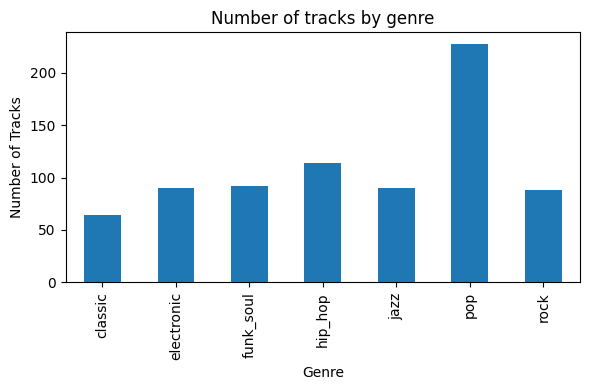

In [4]:
counts = df["genre"].value_counts().sort_index()


plt.figure(figsize=(6,4))
counts.plot(kind="bar")
plt.title("Number of tracks by genre")
plt.xlabel("Genre")
plt.ylabel("Number of Tracks")
plt.tight_layout()
plt.show()

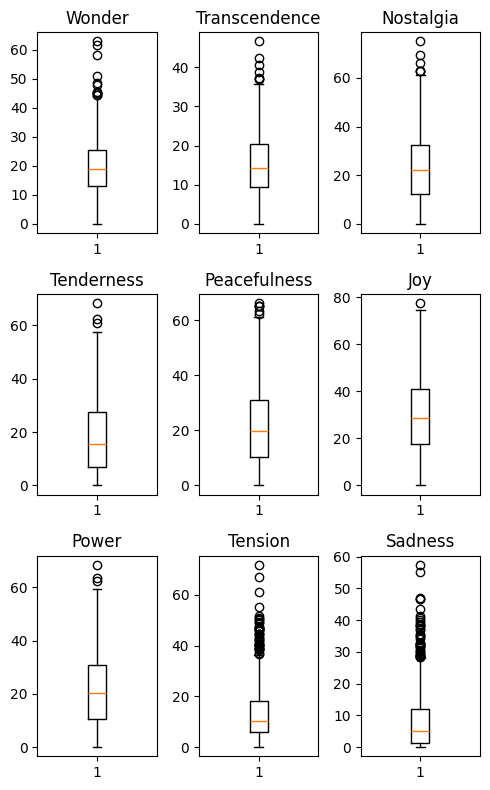

In [5]:
emotions_col = ['Wonder', 'Transcendence', 'Nostalgia',
                'Tenderness', 'Peacefulness', 'Joy',
                'Power','Tension','Sadness']

fig, axs = plt.subplots(3, 3, figsize=(5, 8))
axs = axs.flatten()

for i, emo in enumerate(emotions_col):

    axs[i].boxplot(df[emo])
    axs[i].set_title(f"{emo}")
    # axs[i].set_ylabel(emo)
    # axs[i].set_ylim(1, 5)

plt.tight_layout()
plt.show()

# Recoding The Data

In [6]:
def scale_recoder(x, in_min = 0, in_max = 100, out_min = 1, out_max = 5):
    """
    Recods scores to new scales
    ---
    Default options recod from 0-100 to 1-5
    """
    
    return min(out_max, max(out_min, int(x // (in_max/out_max)) + out_min))

In [52]:
# Linear recoding of the scores
recoded_lin_df = df.copy()
recoded_lin_df[emotions_col] = recoded_lin_df[emotions_col].map(scale_recoder)
recoded_lin_df.head()

,artist,title,Wonder,Transcendence,Nostalgia,Tenderness,Peacefulness,Joy,Power,Tension,Sadness,Spotify ID,Youtube ID,genre,Path
0,The Thrillseekers,Synaesthesia (Fly Away) - Radio Edit,1,1,1,1,1,3,3,2,1,5QdgpcfAw8EbsupH0B6BpI,NaN,electronic,tracks/5QdgpcfAw8EbsupH0B6BpI.mp3
1,Jorge Ben,Ponta de lanÃ¯Â¿Â½a africano (Umbabarauma),2,1,1,1,1,3,2,1,1,0jayFuH5lbwOOVeJnwDgGf,NaN,jazz,tracks/0jayFuH5lbwOOVeJnwDgGf.mp3
2,Lamb,Heaven,1,1,2,1,1,1,2,1,1,0bjTW3zBohWdYy2z1Sf5hJ,NaN,electronic,tracks/0bjTW3zBohWdYy2z1Sf5hJ.mp3
3,Milton Nascimento,Cais,1,1,1,1,2,1,1,1,1,1PVLHOm7WUbZMChq8JAFW9,NaN,jazz,tracks/1PVLHOm7WUbZMChq8JAFW9.mp3
4,Kylie Minogue,Please Stay (7th District Radio Mix),1,1,1,1,1,2,2,1,1,5MqHbBqicUU0wyXwk7TJR7,NaN,pop,tracks/5MqHbBqicUU0wyXwk7TJR7.mp3


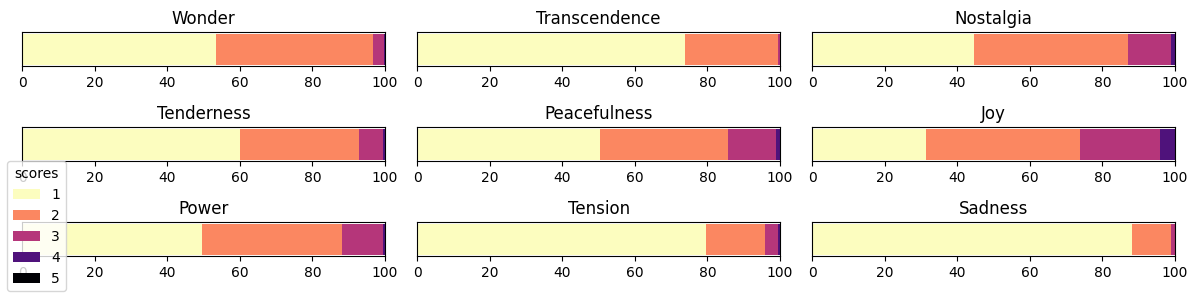

In [44]:
scores = [1, 2, 3, 4, 5]
cmap = plt.cm.magma_r
colors = cmap(np.linspace(0, 1, len(scores)))

fig, axs = plt.subplots(3, 3, figsize=(12, 3), sharey=True)
axs = axs.flatten()


for i, col in enumerate(emotions_col):

    pct = (
        recoded_lin_df[col]
        .value_counts(normalize=True)
        .reindex(scores, fill_value=0)
        * 100
    )

    bottom = 0
    for score, color in zip(scores, colors):
        axs[i].barh(
            0,
            pct[score],
            left=bottom,
            color=color
        )
        bottom += pct[score]

    axs[i].set_title(col)
    axs[i].set_xlim(0,100)
    axs[i].set_yticks([])
    # axs[i].set_ylim(0, 100)

# axs[0].set_xlabel("Percentage (%)")
# axs[0].legend(title="Score", ncol=5, bbox_to_anchor=(0, -0.25), loc="best")

plt.figlegend(title = 'scores', labels = [1,2,3,4,5], loc=3)

plt.tight_layout()
plt.show()

In [51]:
# Quantile Recoding
all_scores = df[emotions_col].to_numpy().ravel()
cuts = np.percentile(all_scores, [20, 40, 60, 80])


recoded_quantile_df = df.copy()
recoded_quantile_df[emotions_col] = np.digitize(recoded_quantile_df[emotions_col], bins=cuts) + 1
recoded_quantile_df.head()

,artist,title,Wonder,Transcendence,Nostalgia,Tenderness,Peacefulness,Joy,Power,Tension,Sadness,Spotify ID,Youtube ID,genre,Path
0,The Thrillseekers,Synaesthesia (Fly Away) - Radio Edit,3,3,3,2,1,5,5,4,1,5QdgpcfAw8EbsupH0B6BpI,NaN,electronic,tracks/5QdgpcfAw8EbsupH0B6BpI.mp3
1,Jorge Ben,Ponta de lanÃ¯Â¿Â½a africano (Umbabarauma),4,3,2,1,3,5,5,3,1,0jayFuH5lbwOOVeJnwDgGf,NaN,jazz,tracks/0jayFuH5lbwOOVeJnwDgGf.mp3
2,Lamb,Heaven,2,3,4,3,3,3,4,3,2,0bjTW3zBohWdYy2z1Sf5hJ,NaN,electronic,tracks/0bjTW3zBohWdYy2z1Sf5hJ.mp3
3,Milton Nascimento,Cais,3,2,3,3,4,1,1,2,3,1PVLHOm7WUbZMChq8JAFW9,NaN,jazz,tracks/1PVLHOm7WUbZMChq8JAFW9.mp3
4,Kylie Minogue,Please Stay (7th District Radio Mix),3,2,2,1,2,5,5,3,1,5MqHbBqicUU0wyXwk7TJR7,NaN,pop,tracks/5MqHbBqicUU0wyXwk7TJR7.mp3


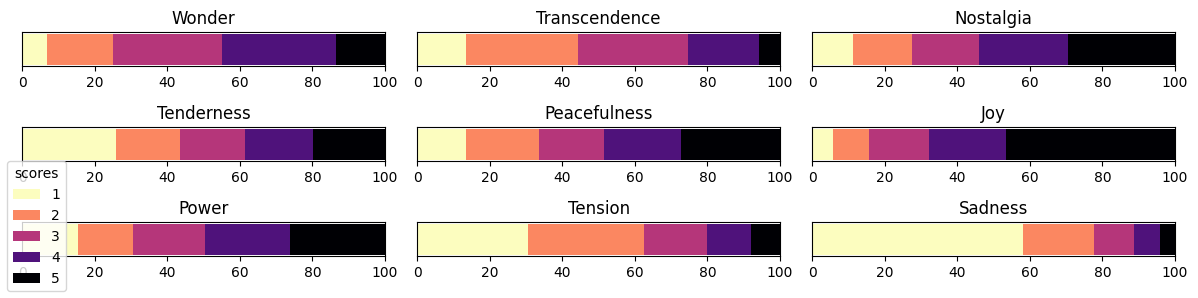

In [43]:
fig, axs = plt.subplots(3, 3, figsize=(12, 3), sharey=True)
axs = axs.flatten()

for i, col in enumerate(emotions_col):

    pct = (
        recoded_quantile_df[col]
        .value_counts(normalize=True)
        .reindex(scores, fill_value=0)
        * 100
    )

    bottom = 0
    for score, color in zip(scores, colors):
        axs[i].barh(
            0,
            pct[score],
            left=bottom,
            color=color
        )
        bottom += pct[score]

    axs[i].set_title(col)
    axs[i].set_xlim(0,100)
    axs[i].set_yticks([])
    # axs[i].set_ylim(0, 100)

# axs[0].set_xlabel("Percentage (%)")
# axs[0].legend(title="Score", ncol=5, bbox_to_anchor=(0, -0.25), loc="best")

plt.figlegend(title = 'scores', labels = [1,2,3,4,5], loc=3)

plt.tight_layout()
plt.show()

In [50]:
from scipy import stats

# convert to numpy array and remove NaNs
data = np.asarray(all_scores)
data = data[~np.isnan(data)]

# estimate parameters
mu, sigma = data.mean(), data.std(ddof=1)

# KS test against fitted normal distribution
ks_stat, p_value = stats.kstest(data, 'norm', args=(mu, sigma))

print(f"KS statistic: {ks_stat:.4f}")
print(f"P-value: {p_value:.4g}")


KS statistic: 0.0820
P-value: 1.007e-40


In [49]:
zscores = (all_scores-mu)/sigma
cuts = [-0.84,-0.24,0.24,0.84] # Distribution normale std

recoded_std_df = df.copy()
recoded_std_df[emotions_col] = recoded_std_df[emotions_col].map(lambda x: (x-score_mean)/score_std)
recoded_std_df[emotions_col] = np.digitize(recoded_std_df[emotions_col], bins=cuts) + 1
recoded_std_df.head()

,artist,title,Wonder,Transcendence,Nostalgia,Tenderness,Peacefulness,Joy,Power,Tension,Sadness,Spotify ID,Youtube ID,genre,Path
0,The Thrillseekers,Synaesthesia (Fly Away) - Radio Edit,2,3,3,2,1,5,5,3,1,5QdgpcfAw8EbsupH0B6BpI,NaN,electronic,tracks/5QdgpcfAw8EbsupH0B6BpI.mp3
1,Jorge Ben,Ponta de lanÃ¯Â¿Â½a africano (Umbabarauma),4,3,1,1,2,5,5,2,1,0jayFuH5lbwOOVeJnwDgGf,NaN,jazz,tracks/0jayFuH5lbwOOVeJnwDgGf.mp3
2,Lamb,Heaven,2,3,4,2,2,2,4,2,2,0bjTW3zBohWdYy2z1Sf5hJ,NaN,electronic,tracks/0bjTW3zBohWdYy2z1Sf5hJ.mp3
3,Milton Nascimento,Cais,2,2,2,3,4,1,1,2,3,1PVLHOm7WUbZMChq8JAFW9,NaN,jazz,tracks/1PVLHOm7WUbZMChq8JAFW9.mp3
4,Kylie Minogue,Please Stay (7th District Radio Mix),2,2,2,1,2,5,5,3,1,5MqHbBqicUU0wyXwk7TJR7,NaN,pop,tracks/5MqHbBqicUU0wyXwk7TJR7.mp3


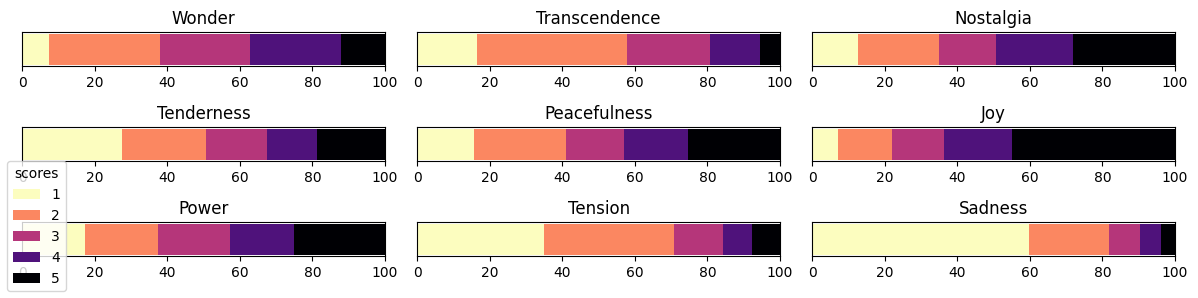

In [42]:
fig, axs = plt.subplots(3, 3, figsize=(12, 3), sharey=True)
axs = axs.flatten()

for i, col in enumerate(emotions_col):

    pct = (
        recoded_std_df[col]
        .value_counts(normalize=True)
        .reindex(scores, fill_value=0)
        * 100
    )

    bottom = 0
    for score, color in zip(scores, colors):
        axs[i].barh(
            0,
            pct[score],
            left=bottom,
            color=color
        )
        bottom += pct[score]

    axs[i].set_title(col)
    axs[i].set_xlim(0,100)
    axs[i].set_yticks([])
    # axs[i].set_ylim(0, 100)

# axs[0].set_xlabel("Percentage (%)")
# axs[0].legend(title="Score", ncol=5, bbox_to_anchor=(0, -0.25), loc="best")

plt.figlegend(title = 'scores', labels = [1,2,3,4,5], loc=3)

plt.tight_layout()
plt.show()

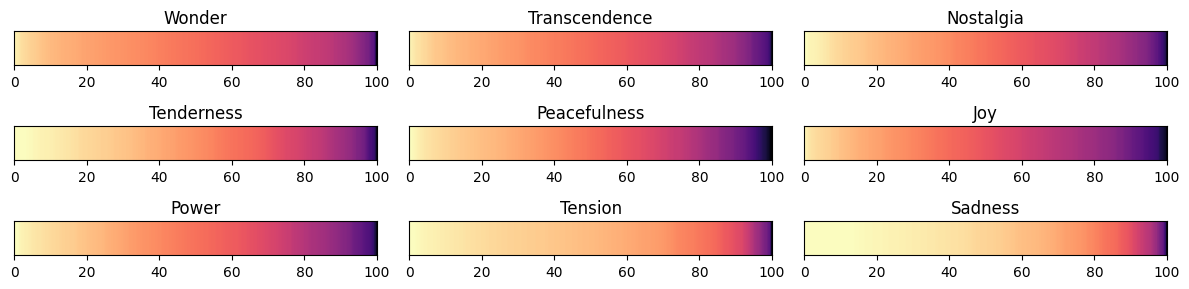

In [41]:

fig, axs = plt.subplots(3, 3, figsize=(12, 3), sharey=True)
axs = axs.flatten()

for i, col in enumerate(emotions_col):

    values = df[col].dropna().values

    # create a smooth gradient by sorting values
    gradient = np.sort(values)[None, :]  # shape (1, N)

    axs[i].imshow(
        gradient,
        aspect="auto",
        cmap=cmap,
        extent=[0, 100, 0, 1]
    )

    axs[i].set_title(col)
    axs[i].set_xlim(0, 100)
    axs[i].set_yticks([])

# colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 100))
sm.set_array([])
# plt.colorbar(sm, ax=axs, orientation="horizontal", fraction=0.05, pad=0.15, label="Score")

plt.tight_layout()
plt.show()

# Emotion Relation

In [13]:
# Corr between the emotion (classic scores)
correlation_matrix = df[emotions_col].corr()

correlation_matrix

,Wonder,Transcendence,Nostalgia,Tenderness,Peacefulness,Joy,Power,Tension,Sadness
Wonder,1.000000,0.505619,0.489214,0.445227,0.419443,0.225021,0.065063,-0.386686,0.211884
Transcendence,0.505619,1.000000,0.328599,0.287457,0.259378,-0.024511,0.200524,-0.031529,0.289296
Nostalgia,0.489214,0.328599,1.000000,0.654560,0.541335,0.042616,-0.107449,-0.515364,0.410144
Tenderness,0.445227,0.287457,0.654560,1.000000,0.747414,-0.238578,-0.374948,-0.549856,0.490625
Peacefulness,0.419443,0.259378,0.541335,0.747414,1.000000,-0.290084,-0.537243,-0.553705,0.371419
Joy,0.225021,-0.024511,0.042616,-0.238578,-0.290084,1.000000,0.601555,-0.122687,-0.505407
Power,0.065063,0.200524,-0.107449,-0.374948,-0.537243,0.601555,1.000000,0.311274,-0.258340
Tension,-0.386686,-0.031529,-0.515364,-0.549856,-0.553705,-0.122687,0.311274,1.000000,-0.148010
Sadness,0.211884,0.289296,0.410144,0.490625,0.371419,-0.505407,-0.258340,-0.148010,1.000000


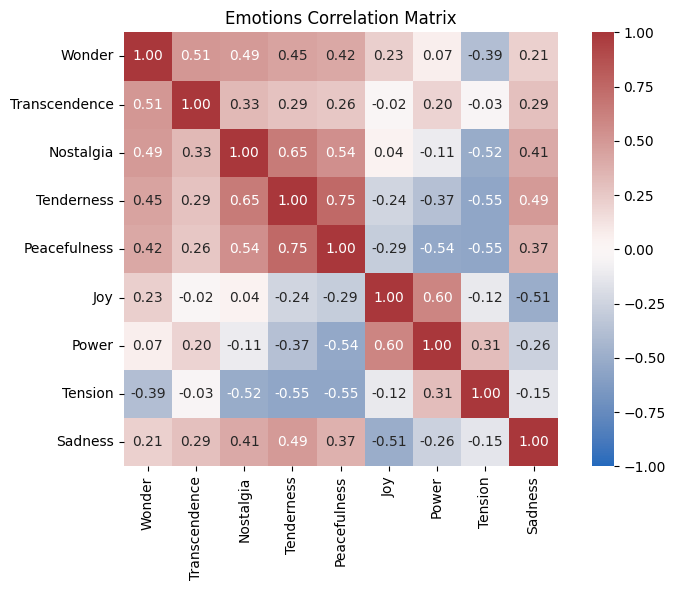

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, 
            annot=True,
            cmap='vlag',
            fmt='.2f',
            vmin= -1,
            vmax=1,
            square=True)
plt.title('Emotions Correlation Matrix')
plt.tight_layout()
plt.show()

In [15]:
# Corr between the emotions (linear recoded scores)
lin_correlation_matrix = recoded_lin_df[emotions_col].corr()

lin_correlation_matrix

,Wonder,Transcendence,Nostalgia,Tenderness,Peacefulness,Joy,Power,Tension,Sadness
Wonder,1.000000,0.370004,0.401574,0.362687,0.350357,0.153237,0.033496,-0.267854,0.178918
Transcendence,0.370004,1.000000,0.233254,0.209429,0.190248,0.007388,0.205029,-0.015879,0.182611
Nostalgia,0.401574,0.233254,1.000000,0.529267,0.459924,0.042593,-0.052008,-0.375887,0.254749
Tenderness,0.362687,0.209429,0.529267,1.000000,0.610119,-0.225216,-0.285586,-0.326964,0.339762
Peacefulness,0.350357,0.190248,0.459924,0.610119,1.000000,-0.266267,-0.427727,-0.369149,0.249107
Joy,0.153237,0.007388,0.042593,-0.225216,-0.266267,1.000000,0.506810,-0.151686,-0.303432
Power,0.033496,0.205029,-0.052008,-0.285586,-0.427727,0.506810,1.000000,0.215254,-0.190623
Tension,-0.267854,-0.015879,-0.375887,-0.326964,-0.369149,-0.151686,0.215254,1.000000,-0.111850
Sadness,0.178918,0.182611,0.254749,0.339762,0.249107,-0.303432,-0.190623,-0.111850,1.000000


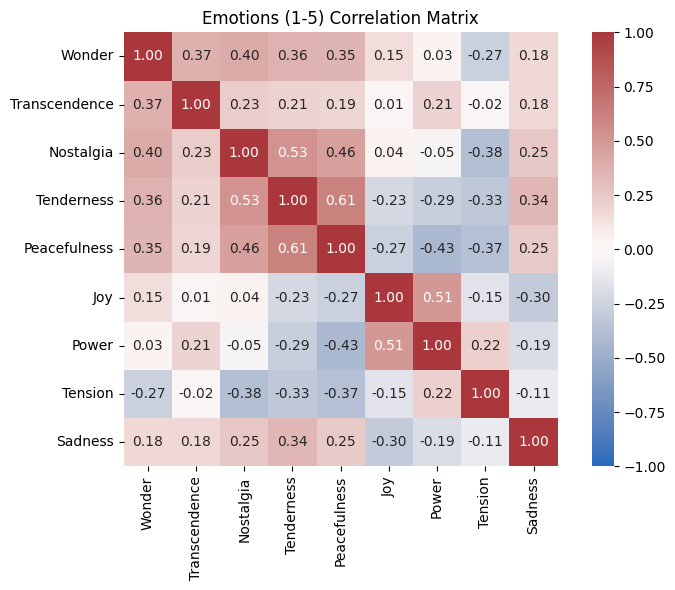

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(lin_correlation_matrix, 
            annot=True,
            cmap='vlag',
            fmt='.2f',
            vmin= -1,
            vmax=1,
            square=True)
plt.title('Emotions (1-5) Correlation Matrix')
plt.tight_layout()
plt.show()

In [17]:
# Corr between the emotions (quantile recoded scores)
quant_correlation_matrix = recoded_quantile_df[emotions_col].corr()

quant_correlation_matrix

,Wonder,Transcendence,Nostalgia,Tenderness,Peacefulness,Joy,Power,Tension,Sadness
Wonder,1.000000,0.483325,0.485393,0.432910,0.455543,0.129474,0.020141,-0.403318,0.205260
Transcendence,0.483325,1.000000,0.282404,0.269184,0.234289,-0.036945,0.155326,-0.044524,0.271808
Nostalgia,0.485393,0.282404,1.000000,0.633354,0.550852,-0.037198,-0.170229,-0.573466,0.369363
Tenderness,0.432910,0.269184,0.633354,1.000000,0.710924,-0.221621,-0.407821,-0.593753,0.430829
Peacefulness,0.455543,0.234289,0.550852,0.710924,1.000000,-0.242437,-0.520032,-0.613610,0.347487
Joy,0.129474,-0.036945,-0.037198,-0.221621,-0.242437,1.000000,0.545843,-0.037419,-0.503919
Power,0.020141,0.155326,-0.170229,-0.407821,-0.520032,0.545843,1.000000,0.331849,-0.235229
Tension,-0.403318,-0.044524,-0.573466,-0.593753,-0.613610,-0.037419,0.331849,1.000000,-0.170588
Sadness,0.205260,0.271808,0.369363,0.430829,0.347487,-0.503919,-0.235229,-0.170588,1.000000


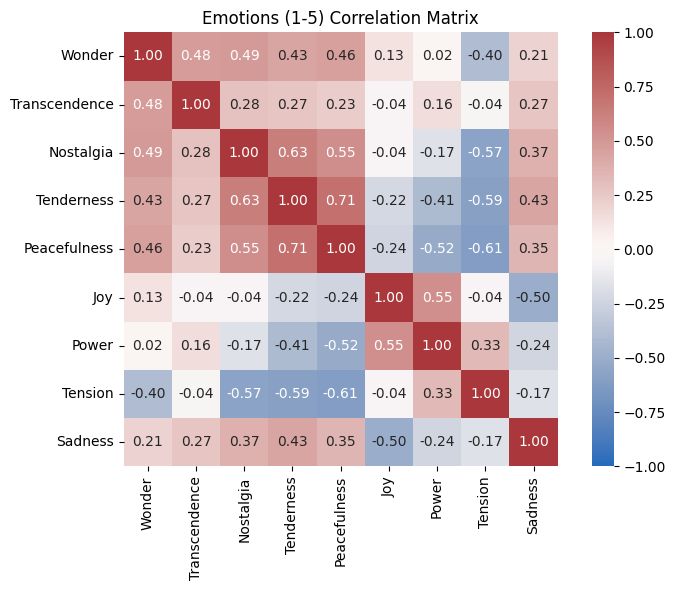

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(quant_correlation_matrix, 
            annot=True,
            cmap='vlag',
            fmt='.2f',
            vmin= -1,
            vmax=1,
            square=True)
plt.title('Emotions (1-5) Correlation Matrix')
plt.tight_layout()
plt.show()

In [19]:
# Corr between the emotions (normal dist recoded scores)
norm_correlation_matrix = recoded_std_df[emotions_col].corr()
norm_correlation_matrix

,Wonder,Transcendence,Nostalgia,Tenderness,Peacefulness,Joy,Power,Tension,Sadness
Wonder,1.000000,0.491989,0.474844,0.413029,0.430267,0.137378,0.056129,-0.374312,0.202783
Transcendence,0.491989,1.000000,0.265309,0.251148,0.220135,-0.026596,0.175375,-0.024820,0.271063
Nostalgia,0.474844,0.265309,1.000000,0.632391,0.552662,-0.041981,-0.164742,-0.568455,0.358467
Tenderness,0.413029,0.251148,0.632391,1.000000,0.716977,-0.244826,-0.414060,-0.577530,0.423027
Peacefulness,0.430267,0.220135,0.552662,0.716977,1.000000,-0.272578,-0.537277,-0.588838,0.356589
Joy,0.137378,-0.026596,-0.041981,-0.244826,-0.272578,1.000000,0.528305,-0.050063,-0.518624
Power,0.056129,0.175375,-0.164742,-0.414060,-0.537277,0.528305,1.000000,0.314102,-0.237001
Tension,-0.374312,-0.024820,-0.568455,-0.577530,-0.588838,-0.050063,0.314102,1.000000,-0.144008
Sadness,0.202783,0.271063,0.358467,0.423027,0.356589,-0.518624,-0.237001,-0.144008,1.000000


In [20]:
#distance between the corr matrix of the recoded scores and the original
lin_dist = np.linalg.norm(correlation_matrix - lin_correlation_matrix) / np.linalg.norm(correlation_matrix)
quant_dist = np.linalg.norm(correlation_matrix - quant_correlation_matrix) / np.linalg.norm(correlation_matrix)
norm_dist = np.linalg.norm(correlation_matrix - norm_correlation_matrix) / np.linalg.norm(correlation_matrix)
print(f'Frobenius Norm : \n- linear recoding = {lin_dist:.3f}\n- quantile recoding = {quant_dist:.3f}\n- normal dist. recoding = {norm_dist:.3f}')

Frobenius Norm : 
- linear recoding = 0.196
- quantile recoding = 0.078
- normal dist. recoding = 0.074


In [21]:
lin_mse = np.mean((correlation_matrix - lin_correlation_matrix) ** 2)
quant_mse = np.mean((correlation_matrix - quant_correlation_matrix) ** 2)
norm_mse = np.mean((correlation_matrix - norm_correlation_matrix) ** 2)

print(f'MSE : \n- linear recoding = {lin_mse:.3f}\n- quantile recoding = {quant_mse:.3f}\n- normal dist. recoding = {norm_mse:.3f}')

MSE : 
- linear recoding = 0.010
- quantile recoding = 0.002
- normal dist. recoding = 0.001


In [22]:
idx = np.triu_indices_from(correlation_matrix, k=1)
v_og = correlation_matrix.to_numpy()[idx]
v_lin = lin_correlation_matrix.to_numpy()[idx]
v_quant = quant_correlation_matrix.to_numpy()[idx]
v_norm = norm_correlation_matrix.to_numpy()[idx]

lin_sim = np.corrcoef(v_og,v_lin)[0][1]
quant_sim = np.corrcoef(v_og,v_quant)[0][1]
norm_sim = np.corrcoef(v_og,v_norm)[0][1]

print(f'Structural Similarity : \n- linear recoding = {lin_sim:.3f}\n- quantile recoding = {quant_sim:.3f}\n- normal dist. recoding = {norm_sim:.3f}')

Structural Similarity : 
- linear recoding = 0.992
- quantile recoding = 0.996
- normal dist. recoding = 0.996


In [23]:
quant_allscore = recoded_quantile_df[emotions_col].to_numpy().ravel()
lin_allscore = recoded_lin_df[emotions_col].to_numpy().ravel()

quant_r = np.corrcoef(all_scores, quant_allscore)
lin_r = np.corrcoef(all_scores, lin_allscore)

print(f'Correlation :\n- Linear recoding = {lin_r[0][1]:.3f}\n- Quantile recoding = {quant_r[0][1]:.3f}')

Correlation :
- Linear recoding = 0.914
- Quantile recoding = 0.925


# ACP

In [53]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[emotions_col])

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print(f'Variance expliquée : {pca.explained_variance_ratio_}')

Variance expliquée : [0.41627671 0.21520839 0.13950632 0.07023586 0.04548758 0.03867184
 0.03213618 0.02320501 0.01927212]


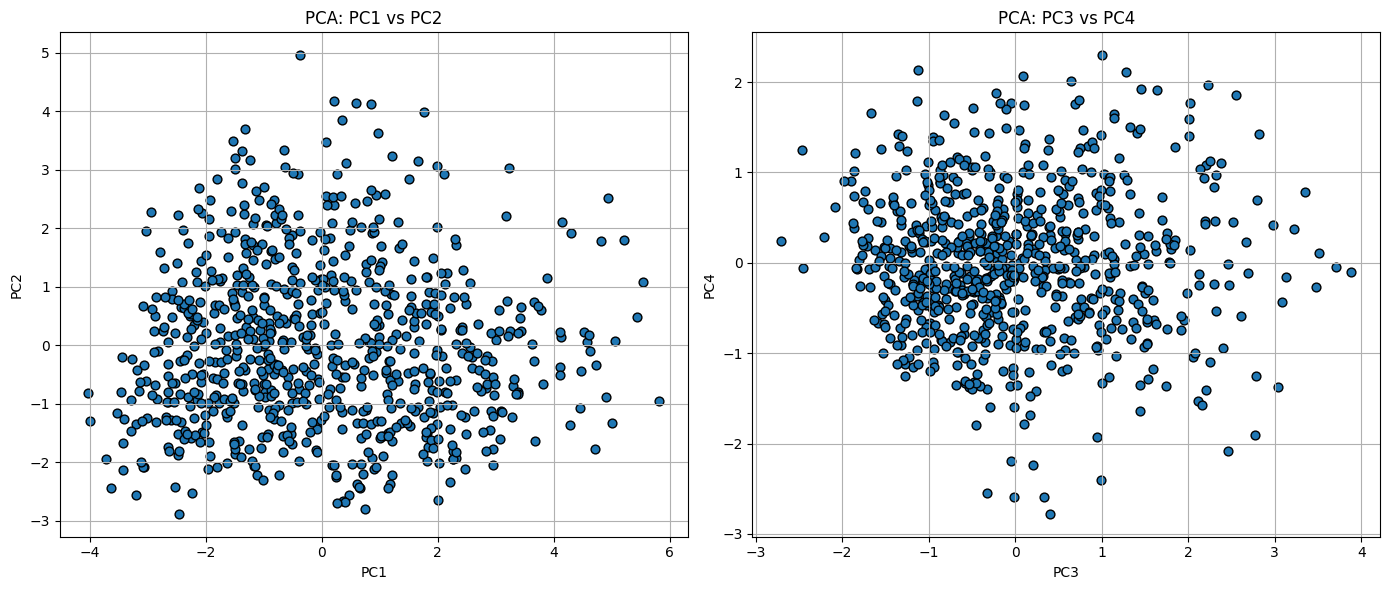

In [54]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

axs[0].scatter(X_pca[:, 0], X_pca[:, 1], edgecolor='k', s=40)
axs[0].set_xlabel('PC1')
axs[0].set_ylabel('PC2')
axs[0].set_title('PCA: PC1 vs PC2')
axs[0].grid(True)

axs[1].scatter(X_pca[:, 2], X_pca[:, 3], edgecolor='k', s=40)
axs[1].set_xlabel('PC3')
axs[1].set_ylabel('PC4')
axs[1].set_title('PCA: PC3 vs PC4')
axs[1].grid(True)

plt.tight_layout()
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


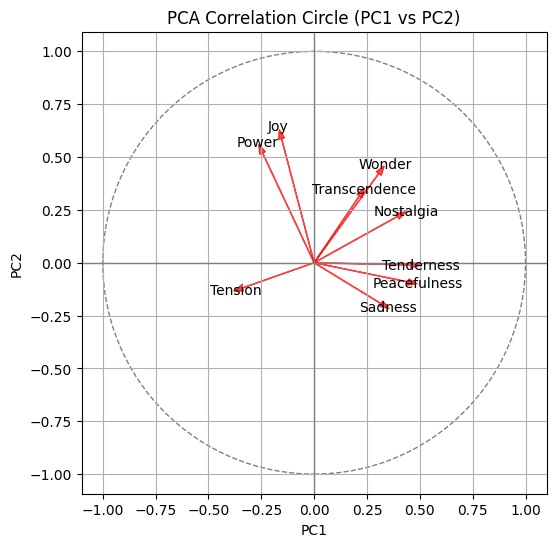

In [55]:
loadings = pca.components_.T

plt.figure(figsize=(6, 6))
plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
plt.gca().add_artist(circle)

for i in range(len(emotions_col)):
    plt.arrow(0, 0, loadings[i, 0], loadings[i, 1],
              color='red', alpha=0.7, head_width=0.03)
    plt.text(loadings[i, 0]*1.1, loadings[i, 1]*1.1,
             emotions_col[i], color='k', ha='center', va='center')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Correlation Circle (PC1 vs PC2)')
plt.xlim(-1.1, 1.1)

plt.ylim(-1.1, 1.1)
plt.gca().set_aspect('equal', adjustable='datalim')
plt.grid(True)
plt.show()

# MDS

c:\Users\paulz\Desktop\MJF-GEMS-Annotations\venv\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
c:\Users\paulz\Desktop\MJF-GEMS-Annotations\venv\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


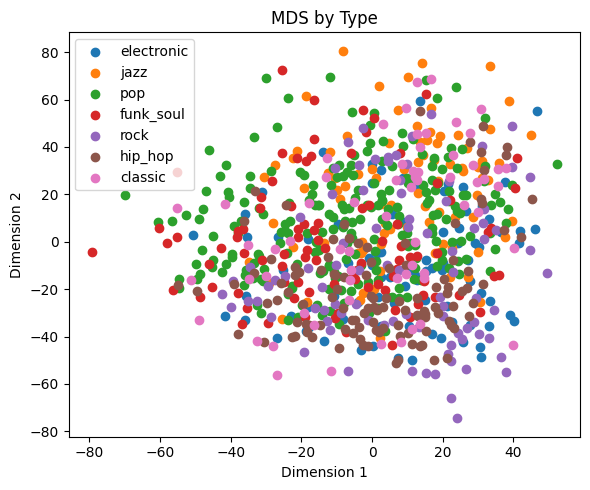

In [56]:
X = df.select_dtypes(include="number")
labels = df["genre"]

mds = MDS(n_components=2, random_state=42)
X_mds = mds.fit_transform(X)

plt.figure(figsize=(6,5))
for t in labels.unique():
    idx = labels == t
    plt.scatter(X_mds[idx, 0], X_mds[idx, 1], label=t)

plt.legend()
plt.title("MDS by Type")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.tight_layout()
plt.show()

# Train/Test Split

In [57]:
# Split dataset
train_df, test_df = train_test_split(df, test_size=0.2, random_state=1)

train_df.to_csv('train.csv', index=False)
test_df.to_csv('test.csv', index=False)